In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load one fused file
path = "spike_features_preview/angry/angry_00002_fusion.npz"
data = np.load(path)

print("Keys:", list(data.keys()))

# Inspect shape and value range
fused = data["fused"]
print("Shape:", fused.shape)
print("Min:", fused.min(), "Max:", fused.max(), "Mean:", fused.mean())

# Show a small time slice numerically
print("\nSample slice (first 10 timesteps):")
print(fused[0, :10, :10])  # show first 10 timesteps & 10 neurons


Keys: ['video_embeddings', 'audio_mel', 'fused', 'emotion']
Shape: (1, 64, 573)
Min: 0.0 Max: 1.0 Mean: 0.26698843

Sample slice (first 10 timesteps):
[[0. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 0.]]


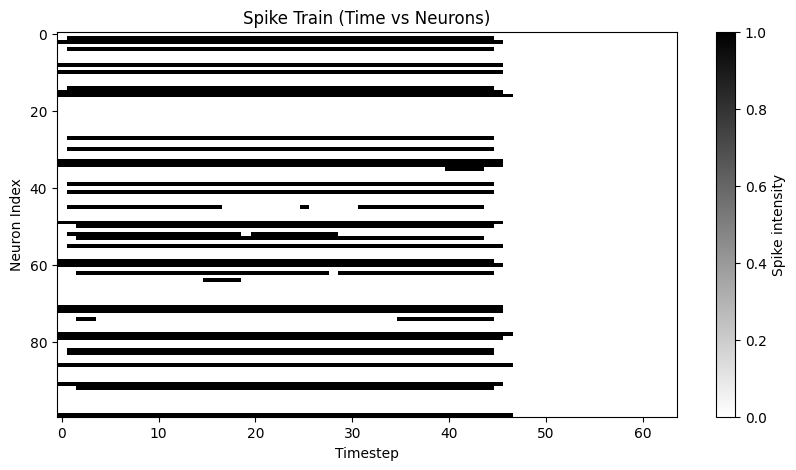

In [2]:
plt.figure(figsize=(10, 5))
# Select one example (batch 0)
spikes = fused[0, :, :100]  # first 100 neurons
plt.imshow(spikes.T, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.title("Spike Train (Time vs Neurons)")
plt.xlabel("Timestep")
plt.ylabel("Neuron Index")
plt.colorbar(label="Spike intensity")
plt.show()


Keys: ['video_embeddings', 'audio_mel', 'fused', 'emotion']
Shape: (1, 64, 573) | Min: 0.000 | Max: 1.000 | Mean: 0.267


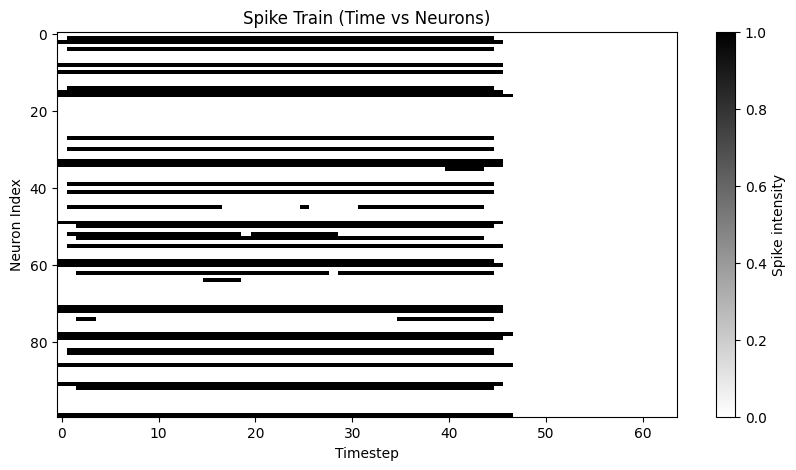

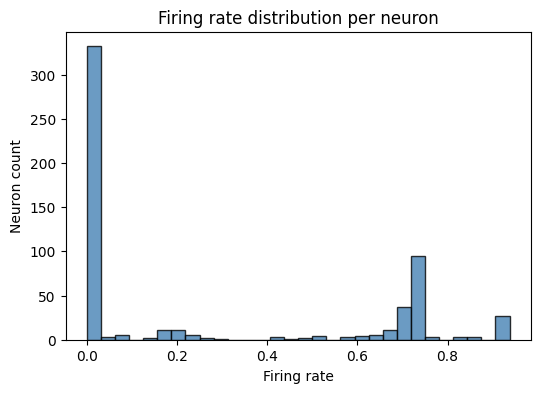

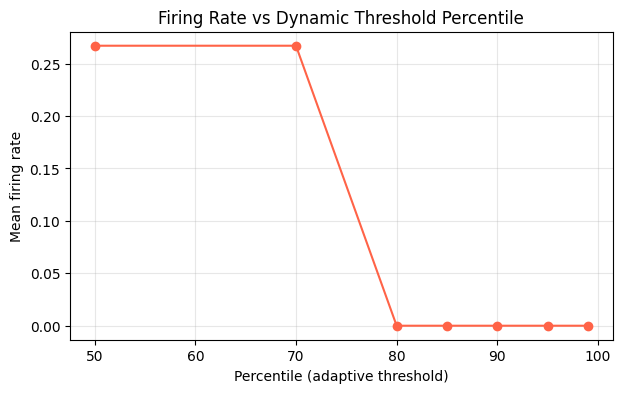

Percentile  50% → Threshold 0.0000 → Mean firing rate 0.2670
Percentile  70% → Threshold 0.0000 → Mean firing rate 0.2670
Percentile  80% → Threshold 1.0000 → Mean firing rate 0.0000
Percentile  85% → Threshold 1.0000 → Mean firing rate 0.0000
Percentile  90% → Threshold 1.0000 → Mean firing rate 0.0000
Percentile  95% → Threshold 1.0000 → Mean firing rate 0.0000
Percentile  99% → Threshold 1.0000 → Mean firing rate 0.0000


In [3]:
# ===============================
# 🧩 Spike Feature Visualizer
# ===============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# ---------- CONFIG ----------
# Path to a sample Stage C file
path = Path("spike_features_preview/angry/angry_00002_fusion.npz")
percentiles_to_test = [50, 70, 80, 85, 90, 95, 99]  # for dynamic sweep
# ============================

# ---------- LOAD ----------
data = np.load(path)
print("Keys:", list(data.keys()))

fused = data["fused"]
print(f"Shape: {fused.shape} | Min: {fused.min():.3f} | Max: {fused.max():.3f} | Mean: {fused.mean():.3f}")

# Convert to torch for thresholding ops
x = torch.tensor(fused, dtype=torch.float32)

# ---------- VISUALIZE SPIKE TRAIN ----------
plt.figure(figsize=(10, 5))
spikes = fused[0, :, :100]  # first 100 neurons
plt.imshow(spikes.T, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.title("Spike Train (Time vs Neurons)")
plt.xlabel("Timestep")
plt.ylabel("Neuron Index")
plt.colorbar(label="Spike intensity")
plt.show()

# ---------- FIRING RATE HISTOGRAM ----------
rates = fused.mean(axis=1).flatten()
plt.figure(figsize=(6, 4))
plt.hist(rates, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
plt.title("Firing rate distribution per neuron")
plt.xlabel("Firing rate")
plt.ylabel("Neuron count")
plt.show()

# ---------- DYNAMIC THRESHOLD SWEEP ----------
def dynamic_threshold(x, percentile):
    thr = torch.quantile(x, percentile / 100.0)
    return (x > thr).float(), thr.item()

rates_dyn, thrs = [], []
for p in percentiles_to_test:
    s, thr_val = dynamic_threshold(x, p)
    rate = s.mean().item()
    rates_dyn.append(rate)
    thrs.append(thr_val)

plt.figure(figsize=(7, 4))
plt.plot(percentiles_to_test, rates_dyn, marker="o", color="tomato")
plt.title("Firing Rate vs Dynamic Threshold Percentile")
plt.xlabel("Percentile (adaptive threshold)")
plt.ylabel("Mean firing rate")
plt.grid(alpha=0.3)
plt.show()

for p, r, t in zip(percentiles_to_test, rates_dyn, thrs):
    print(f"Percentile {p:>3}% → Threshold {t:.4f} → Mean firing rate {r:.4f}")
